In [1]:
from albumentations import ToTensorV2
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
import os

from utils.dataset import PandasDataset
from utils.metrics import model_checkpoint
from utils.train import train_model
from utils.models import EfficientNetApi

In [2]:
seed = 42
shuffle = True
batch_size = 6
num_workers = 4
output_classes = 5
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

ROOT_DIR = '../../..'

data_dir = '../../../../dataset'
images_dir = os.path.join(data_dir, 'tiles')

Using device: cuda


In [3]:
load_model = efficientnet_b0(
     weights=EfficientNet_B0_Weights.DEFAULT
)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=0.6)
model = model.to(device)

In [4]:
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

Using device: cuda


In [5]:
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Registros originais: {len(df_train_)}")

df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")

df_entropy_sorted = df_entropy.sort_values(by="difficulty_score", ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy_sorted) * 0.2)
df_entropy_top50 = df_entropy_sorted.head(n_remove)


df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top50['image_id'])].reset_index(drop=True)

print(f"Registros no df_entropy: {len(df_entropy)}")
print(f"Registros no df_entropy_top50: {len(df_entropy_top50)}")
print(f"Registros filtrados (df_train_): {len(df_train_)}")

df_train_.columns = df_train_.columns.str.strip()

# Criar índices de treino e validação
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

# Separar em treino e validação
df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Carregar teste
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

print(f"\nTreino: {len(df_train)} registros")
print(f"Validação: {len(df_val)} registros")
print(f"Teste: {len(df_test)} registros")

Registros originais: 9024
Registros no df_entropy: 903
Registros no df_entropy_top50: 180
Registros filtrados (df_train_): 8844

Treino: 7077 registros
Validação: 1767 registros
Teste: 1592 registros


#### view data

In [6]:
(df_train.shape, df_val.shape, df_test.shape)

((7077, 5), (1767, 5), (1592, 4))

In [7]:
from utils.dataset import RGB2XYZTransform

transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
    # ToTensorV2()
])

valid_transforms = Albu.Compose([
    # RGB2XYZTransform(p=1.0),
    # ToTensorV2()
])

In [8]:
df_train.columns = df_train.columns.str.strip()

train_dataset = PandasDataset(images_dir, df_train, transforms=transforms)
valid_dataset = PandasDataset(images_dir, df_val, transforms=valid_transforms)
test_dataset = PandasDataset(images_dir, df_test, transforms=valid_transforms)

In [9]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, sampler=RandomSampler(train_dataset)
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(valid_dataset)
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(test_dataset)
)

In [10]:
optimizer = optim.Adam(model.parameters(), lr = init_lr / warmup_factor)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier = warmup_factor, total_epoch = warmup_epochs, after_scheduler=scheduler_cosine)

In [11]:
train_model(
    model=model,
    epochs=n_epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    checkpoint=model_checkpoint,
    device=device,
    loss_function=loss_function,
    path_to_save_metrics="logs/b0-entropy.txt",
    path_to_save_model="models/b0-entropy.pth",
    patience=5,
)

Epoch 1/50



100%|██████████| 295/295 [01:39<00:00,  2.98it/s]


VAL_LOSS     0.428
VAL_ACC      Mean: 63.154 | Std: 1.198 | 95% CI: [61.177, 65.082]
VAL_KAPPA    Mean: 0.825 | Std: 0.012 | 95% CI: [0.805, 0.844]
VAL_F1       Mean: 0.582 | Std: 0.013 | 95% CI: [0.562, 0.603]
VAL_RECALL   Mean: 0.582 | Std: 0.013 | 95% CI: [0.562, 0.603]
VAL_PRECISION Mean: 0.585 | Std: 0.013 | 95% CI: [0.564, 0.606]
Epoch 12/50



100%|██████████| 295/295 [01:35<00:00,  3.08it/s]


VAL_LOSS     0.440
VAL_ACC      Mean: 63.749 | Std: 1.178 | 95% CI: [61.800, 65.648]
VAL_KAPPA    Mean: 0.817 | Std: 0.012 | 95% CI: [0.796, 0.836]
VAL_F1       Mean: 0.588 | Std: 0.013 | 95% CI: [0.567, 0.609]
VAL_RECALL   Mean: 0.582 | Std: 0.012 | 95% CI: [0.561, 0.603]
VAL_PRECISION Mean: 0.604 | Std: 0.013 | 95% CI: [0.582, 0.625]
Epoch 13/50



...

VAL_LOSS     0.619
VAL_ACC      Mean: 63.614 | Std: 1.173 | 95% CI: [61.686, 65.535]
VAL_KAPPA    Mean: 0.837 | Std: 0.011 | 95% CI: [0.818, 0.856]
VAL_F1       Mean: 0.580 | Std: 0.012 | 95% CI: [0.560, 0.600]
VAL_RECALL   Mean: 0.584 | Std: 0.012 | 95% CI: [0.564, 0.604]
VAL_PRECISION Mean: 0.583 | Std: 0.012 | 95% CI: [0.563, 0.604]
Epoch 25/50



100%|██████████| 295/295 [01:32<00:00,  3.18it/s]


VAL_LOSS     0.572
VAL_ACC      Mean: 66.154 | Std: 1.156 | 95% CI: [64.177, 67.968]
VAL_KAPPA    Mean: 0.842 | Std: 0.011 | 95% CI: [0.823, 0.862]
VAL_F1       Mean: 0.603 | Std: 0.013 | 95% CI: [0.583, 0.624]
VAL_RECALL   Mean: 0.602 | Std: 0.012 | 95% CI: [0.582, 0.622]
VAL_PRECISION Mean: 0.613 | Std: 0.013 | 95% CI: [0.592, 0.634]
Epoch 26/50



100%|██████████| 295/295 [01:32<00:00,  3.20it/s]


VAL_LOSS     0.624
VAL_ACC      Mean: 64.717 | Std: 1.173 | 95% CI: [62.762, 66.610]
VAL_KAPPA    Mean: 0.835 | Std: 0.012 | 95% CI: [0.814, 0.854]
VAL_F1       Mean: 0.586 | Std: 0.013 | 95% CI: [0.566, 0.606]
VAL_RECALL   Mean: 0.588 | Std: 0.012 | 95% CI: [0.568, 0.608]
VAL_PRECISION Mean: 0.593 | Std: 0.013 | 95% CI: [0.571, 0.613]

Early stopping at epoch 26. No improvement for 5 epochs.
Best epoch: 21 with kappa: 0.8439


# tests

In [10]:
from utils.metrics import evaluation, format_metrics
model.load_state_dict(
    torch.load(f"models/b0-entropy.pth")
)
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print(result)

100%|██████████| 266/266 [01:18<00:00,  3.39it/s]


VAL_ACC      Mean: 62.929 | Std: 1.217 | 95% CI: [60.930, 64.824]
VAL_KAPPA    Mean: 0.833 | Std: 0.013 | 95% CI: [0.812, 0.853]
VAL_F1       Mean: 0.574 | Std: 0.013 | 95% CI: [0.553, 0.594]
VAL_RECALL   Mean: 0.580 | Std: 0.013 | 95% CI: [0.559, 0.600]
VAL_PRECISION Mean: 0.573 | Std: 0.013 | 95% CI: [0.553, 0.594]


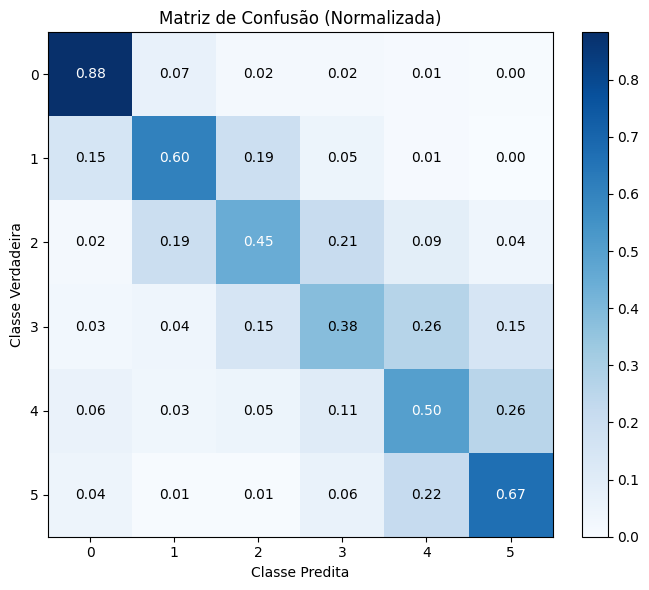

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# sua matriz (exemplo)
cm = np.array(response[0].get("confusion_matrix"))

classes = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(8, 6))
im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Matriz de Confusão (Normalizada)")
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Predita")

# adicionar valores nas células
fmt = ".2f"
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()
